In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('credit_risk_dataset.csv')
data 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:
df = data.copy() 

df = df.rename(columns={'person_age': 'age', 
                          'person_income': 'income',
                          'person_home_ownership': 'home_ownership',
                          'person_emp_length': 'emp_length',
                          'cb_person_default_on_file': 'default_on_file',
                          'cb_person_cred_hist_length': 'cred_hist_length'})
df = df[(df["age"] >= 20) & (df["age"] <= 36)]


df['loan_status'].value_counts()

loan_status
0    23159
1     6504
Name: count, dtype: int64

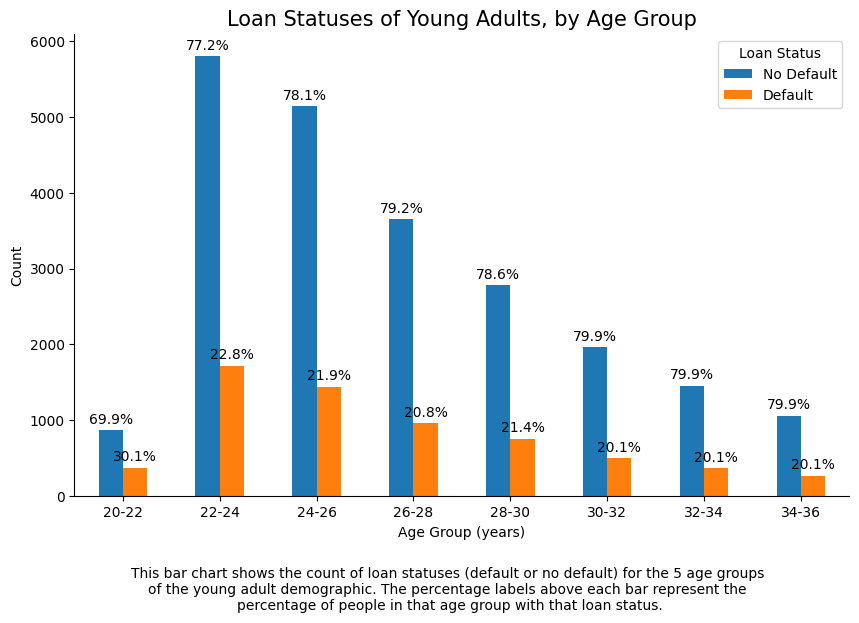

In [5]:
# create interval bins for age and make labels 
bins = [20, 22, 24, 26, 28, 30, 32, 34, 36]
labels = ['20-22', '22-24', '24-26', '26-28', '28-30', '30-32', '32-34', '34-36']
# create new column for age group using pd.cut
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# groupby age group and loan status and counts 
age_group_counts = df.groupby(['age_group', 'loan_status']).size().unstack()

# create percentages for each loan status within each age group
percentages = age_group_counts.div(age_group_counts.sum(axis=1), axis=0) * 100

# create bar chart showing loan status for each age group
fig, ax = plt.subplots(figsize=(10, 6))
age_group_counts.plot(kind='bar', stacked=False, ax=ax)

# add percentage labels above each bar
for container, status in zip(ax.containers, age_group_counts.columns):
    for bar, pct in zip(container, percentages[status]):
        ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

# x and y axis labels 
ax.set_xticklabels(labels, rotation=0)
ax.set_xlabel('Age Group (years)')
ax.set_ylabel('Count')

# remove spines 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# add legend 
ax.legend(title='Loan Status', labels=['No Default', 'Default'], loc='upper right')

# add title 
ax.set_title('Loan Statuses of Young Adults, by Age Group', fontdict={'fontsize':15})

# add caption 
plt.figtext(0.5, -0.08, 
            'This bar chart shows the count of loan statuses (default or no default) for the 5 age groups \nof the young adult demographic. The percentage labels above each bar represent the \npercentage of people in that age group with that loan status.', 
            ha='center')

# save as png 
plt.savefig('press_release_viz.png', bbox_inches='tight')
plt.show()